# Task 5: Interactive Business Dashboard in Streamlit

## DevelopersHub Corporation - Data Science & Analytics Internship

### Objective:
Develop an interactive dashboard for analyzing sales, profit, and segment-wise performance using the Global Superstore Dataset.

### Dataset:
Global Superstore Dataset (Kaggle)

### Features:
- Interactive filters (Region, Category, Sub-Category)
- Total Sales KPI
- Total Profit KPI
- Top 5 Customers by Sales
- Sales by Category chart
- Profit by Region chart

### Tools Used:
Python 3.10, pandas, numpy, matplotlib, seaborn, streamlit, plotly

In [1]:
# ============================================================
# Step 1: Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# ============================================================
# Step 2: Load the Global Superstore Dataset
# ============================================================

# Try different encodings if needed
try:
    df = pd.read_csv('Global_Superstore2.csv', encoding='utf-8')
except:
    try:
        df = pd.read_csv('Global_Superstore2.csv', encoding='latin-1')
    except:
        df = pd.read_csv('Global_Superstore2.csv', encoding='cp1252')

print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset loaded successfully!
Total Rows: 51290
Total Columns: 24


In [5]:
# ============================================================
# Step 3: First Look at the Dataset
# ============================================================

print("First 5 rows:")
df.head()

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [6]:
# ============================================================
# Step 4: Dataset Structure
# ============================================================

print("Dataset Shape:", df.shape)
print()
print("Column Names and Data Types:")
print("-" * 50)
for col in df.columns:
    print(f"  {col:30s} -> {df[col].dtype}")

Dataset Shape: (51290, 24)

Column Names and Data Types:
--------------------------------------------------
  Row ID                         -> int64
  Order ID                       -> object
  Order Date                     -> object
  Ship Date                      -> object
  Ship Mode                      -> object
  Customer ID                    -> object
  Customer Name                  -> object
  Segment                        -> object
  City                           -> object
  State                          -> object
  Country                        -> object
  Postal Code                    -> float64
  Market                         -> object
  Region                         -> object
  Product ID                     -> object
  Category                       -> object
  Sub-Category                   -> object
  Product Name                   -> object
  Sales                          -> float64
  Quantity                       -> int64
  Discount                      

In [7]:
# ============================================================
# Step 5: Check Missing Values
# ============================================================

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Columns with Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

Columns with Missing Values:
             Missing Count  Missing %
Postal Code          41296      80.51

Total Missing Values: 41296


In [8]:
# ============================================================
# Step 6: Clean and Prepare the Dataset
# ============================================================

# Drop unnecessary columns if they exist
cols_to_drop = ['Row ID', 'Postal Code']
for col in cols_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)
        print(f"Dropped column: {col}")

# Convert Order Date to datetime
if 'Order Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df['Year'] = df['Order Date'].dt.year
    df['Month'] = df['Order Date'].dt.month
    df['Month Name'] = df['Order Date'].dt.strftime('%B')
    print("Order Date converted to datetime")
    print("Year, Month, Month Name columns added")

# Fill missing values
df.fillna(0, inplace=True)

print(f"\nDataset after cleaning:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\nData cleaning complete!")

Dropped column: Row ID
Dropped column: Postal Code
Order Date converted to datetime
Year, Month, Month Name columns added

Dataset after cleaning:
Rows: 51290
Columns: 25

Data cleaning complete!


## Exploratory Data Analysis (EDA)

Analyzing key business metrics:
1. Overall KPIs (Sales, Profit, Orders)
2. Sales by Category
3. Sales by Region
4. Top 10 Customers
5. Sales Trend Over Time
6. Profit Analysis

OVERALL BUSINESS KPIs
  Total Sales:      $12,642,501.91
  Total Profit:     $1,467,457.29
  Profit Margin:    11.61%
  Total Orders:     25,035
  Total Customers:  795


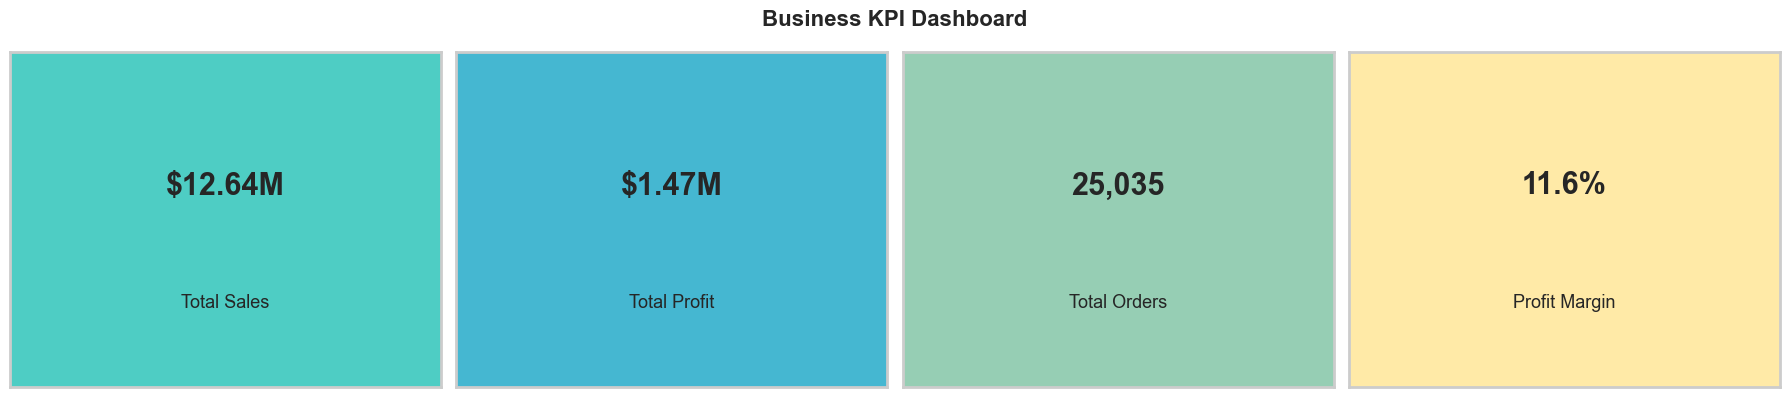

In [9]:
# ============================================================
# Step 7: Overall Business KPIs
# ============================================================

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer Name'].nunique()
profit_margin = (total_profit / total_sales * 100)

print("=" * 55)
print("OVERALL BUSINESS KPIs")
print("=" * 55)
print(f"  Total Sales:      ${total_sales:,.2f}")
print(f"  Total Profit:     ${total_profit:,.2f}")
print(f"  Profit Margin:    {profit_margin:.2f}%")
print(f"  Total Orders:     {total_orders:,}")
print(f"  Total Customers:  {total_customers:,}")

# KPI Visual Cards
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
kpis = [
    ('Total Sales', f'${total_sales/1e6:.2f}M', '#4ECDC4'),
    ('Total Profit', f'${total_profit/1e6:.2f}M', '#45B7D1'),
    ('Total Orders', f'{total_orders:,}', '#96CEB4'),
    ('Profit Margin', f'{profit_margin:.1f}%', '#FFEAA7')
]

for ax, (title, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=22, fontweight='bold',
            transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center',
            fontsize=13, transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)

plt.suptitle('Business KPI Dashboard',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

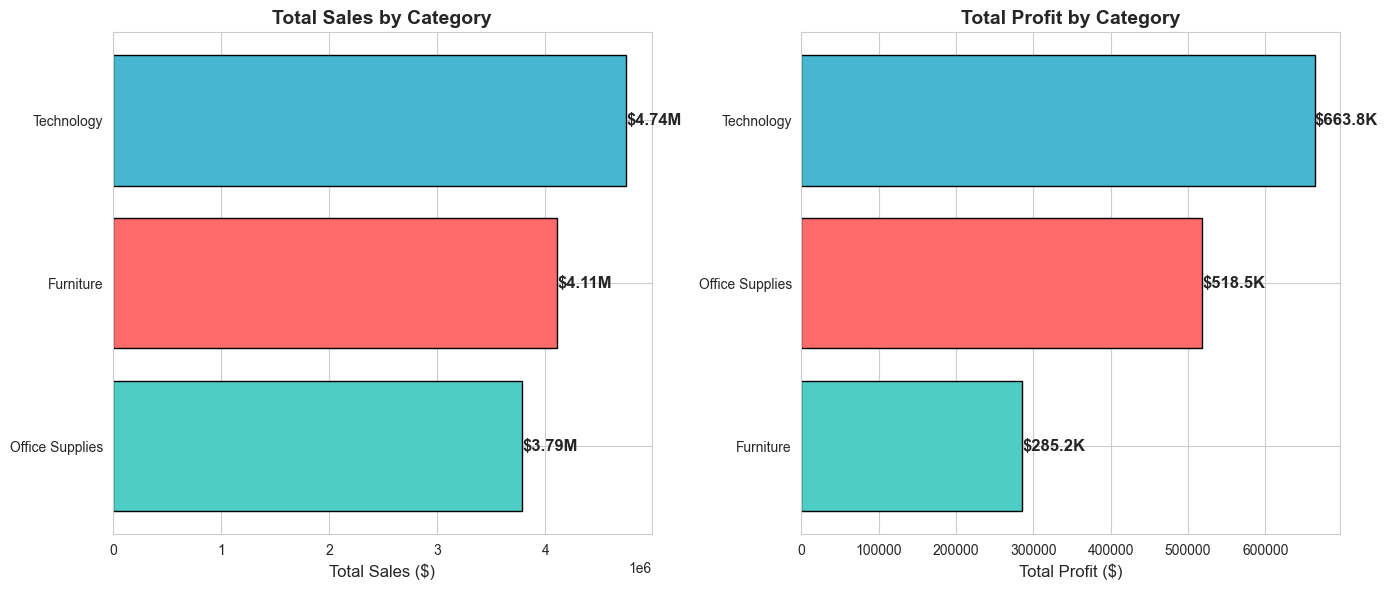

Sales by Category:
  Office Supplies: $3,787,070.23
  Furniture: $4,110,874.19
  Technology: $4,744,557.50


In [10]:
# ============================================================
# Step 8: Sales and Profit by Category
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales by Category
sales_by_cat = df.groupby('Category')['Sales'].sum().sort_values()
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']

bars = axes[0].barh(sales_by_cat.index,
                    sales_by_cat.values,
                    color=colors, edgecolor='black')
for bar, val in zip(bars, sales_by_cat.values):
    axes[0].text(val + 1000, bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:.2f}M',
                 va='center', fontsize=12, fontweight='bold')
axes[0].set_title('Total Sales by Category',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Sales ($)', fontsize=12)

# Profit by Category
profit_by_cat = df.groupby('Category')['Profit'].sum().sort_values()
bars2 = axes[1].barh(profit_by_cat.index,
                     profit_by_cat.values,
                     color=colors, edgecolor='black')
for bar, val in zip(bars2, profit_by_cat.values):
    axes[1].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'${val/1e3:.1f}K',
                 va='center', fontsize=12, fontweight='bold')
axes[1].set_title('Total Profit by Category',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)', fontsize=12)

plt.tight_layout()
plt.show()

print("Sales by Category:")
for cat, sales in sales_by_cat.items():
    print(f"  {cat}: ${sales:,.2f}")

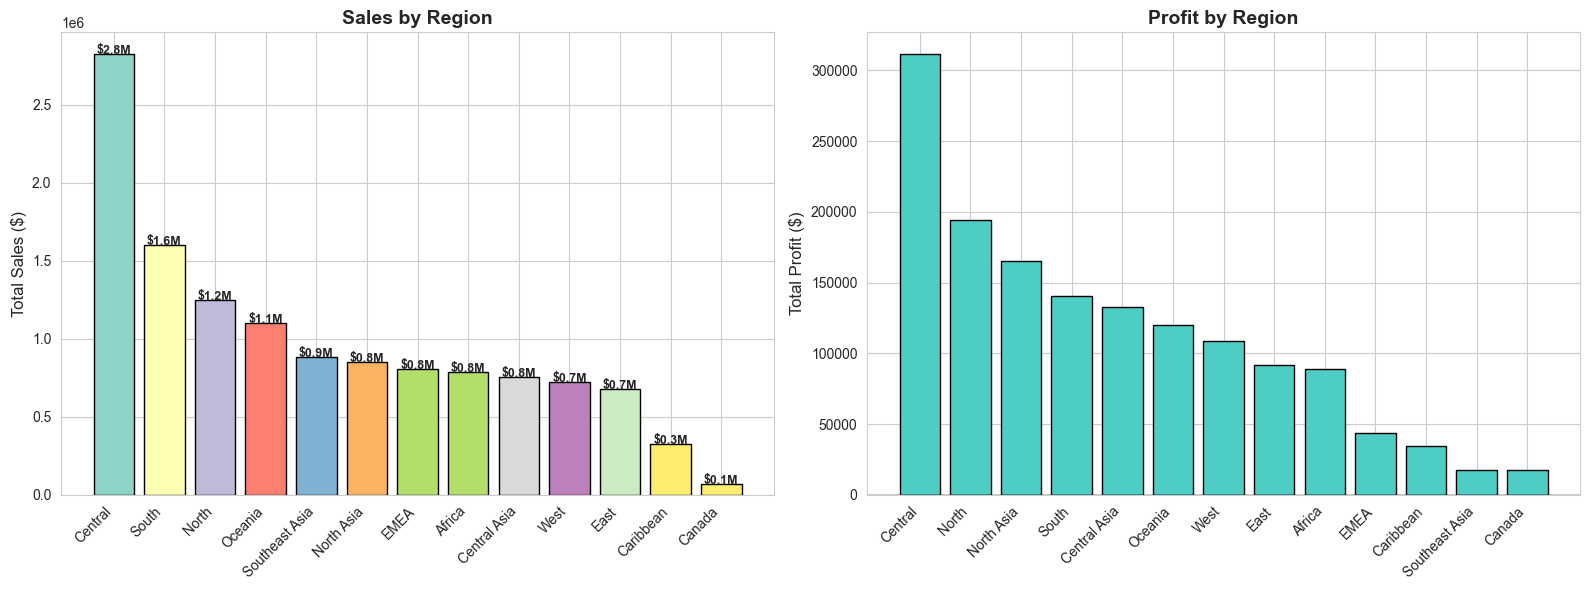

In [11]:
# ============================================================
# Step 9: Sales and Profit by Region
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Region
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

colors = plt.cm.Set3(np.linspace(0, 1, len(sales_by_region)))
bars = axes[0].bar(range(len(sales_by_region)),
                   sales_by_region.values,
                   color=colors, edgecolor='black')
axes[0].set_xticks(range(len(sales_by_region)))
axes[0].set_xticklabels(sales_by_region.index,
                         rotation=45, ha='right')
axes[0].set_title('Sales by Region',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)', fontsize=12)
for bar, val in zip(bars, sales_by_region.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'${val/1e6:.1f}M',
                 ha='center', fontsize=9, fontweight='bold')

# Profit by Region
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
bar_colors = ['#FF6B6B' if v < 0 else '#4ECDC4'
              for v in profit_by_region.values]
bars2 = axes[1].bar(range(len(profit_by_region)),
                    profit_by_region.values,
                    color=bar_colors, edgecolor='black')
axes[1].set_xticks(range(len(profit_by_region)))
axes[1].set_xticklabels(profit_by_region.index,
                         rotation=45, ha='right')
axes[1].set_title('Profit by Region',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)', fontsize=12)
axes[1].axhline(y=0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

Top 5 Customers by Sales:
  1. Tom Ashbrook
     Sales: $40,488.07
     Profit: $6,311.98
     Orders: 30.0

  2. Tamara Chand
     Sales: $37,457.33
     Profit: $8,672.90
     Orders: 36.0

  3. Greg Tran
     Sales: $35,550.95
     Profit: $5,214.13
     Orders: 34.0

  4. Christopher Conant
     Sales: $35,187.08
     Profit: $5,603.33
     Orders: 39.0

  5. Sean Miller
     Sales: $35,170.93
     Profit: $-409.71
     Orders: 28.0



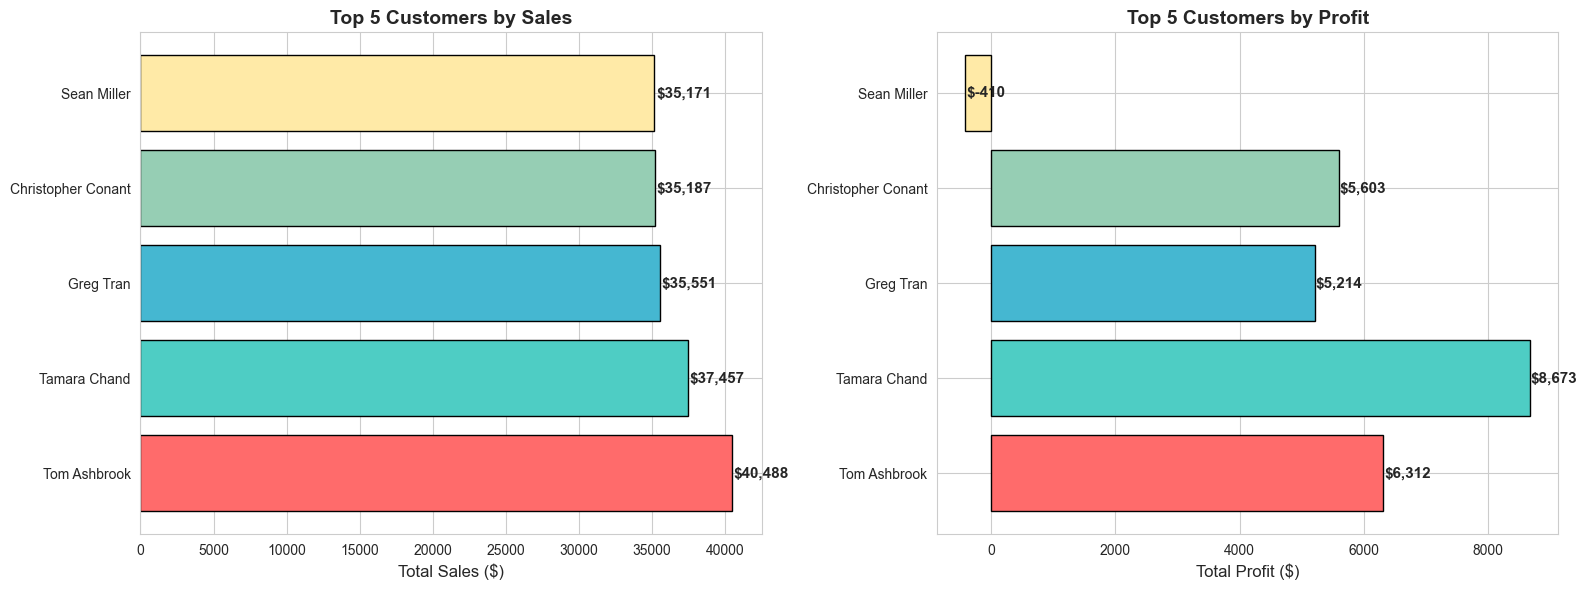

In [12]:
# ============================================================
# Step 10: Top 5 Customers by Sales
# ============================================================

top5_customers = df.groupby('Customer Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).rename(columns={'Order ID': 'Total Orders'})
top5_customers = top5_customers.sort_values(
    'Sales', ascending=False
).head(5)

print("Top 5 Customers by Sales:")
print("=" * 55)
for i, (name, row) in enumerate(top5_customers.iterrows(), 1):
    print(f"  {i}. {name}")
    print(f"     Sales: ${row['Sales']:,.2f}")
    print(f"     Profit: ${row['Profit']:,.2f}")
    print(f"     Orders: {row['Total Orders']}")
    print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# Top 5 by Sales
bars = axes[0].barh(
    top5_customers.index,
    top5_customers['Sales'],
    color=colors, edgecolor='black'
)
for bar, val in zip(bars, top5_customers['Sales']):
    axes[0].text(val + 100,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}',
                 va='center', fontsize=11, fontweight='bold')
axes[0].set_title('Top 5 Customers by Sales',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Sales ($)', fontsize=12)

# Top 5 by Profit
bars2 = axes[1].barh(
    top5_customers.index,
    top5_customers['Profit'],
    color=colors, edgecolor='black'
)
for bar, val in zip(bars2, top5_customers['Profit']):
    axes[1].text(val + 10,
                 bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}',
                 va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Top 5 Customers by Profit',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)', fontsize=12)

plt.tight_layout()
plt.show()

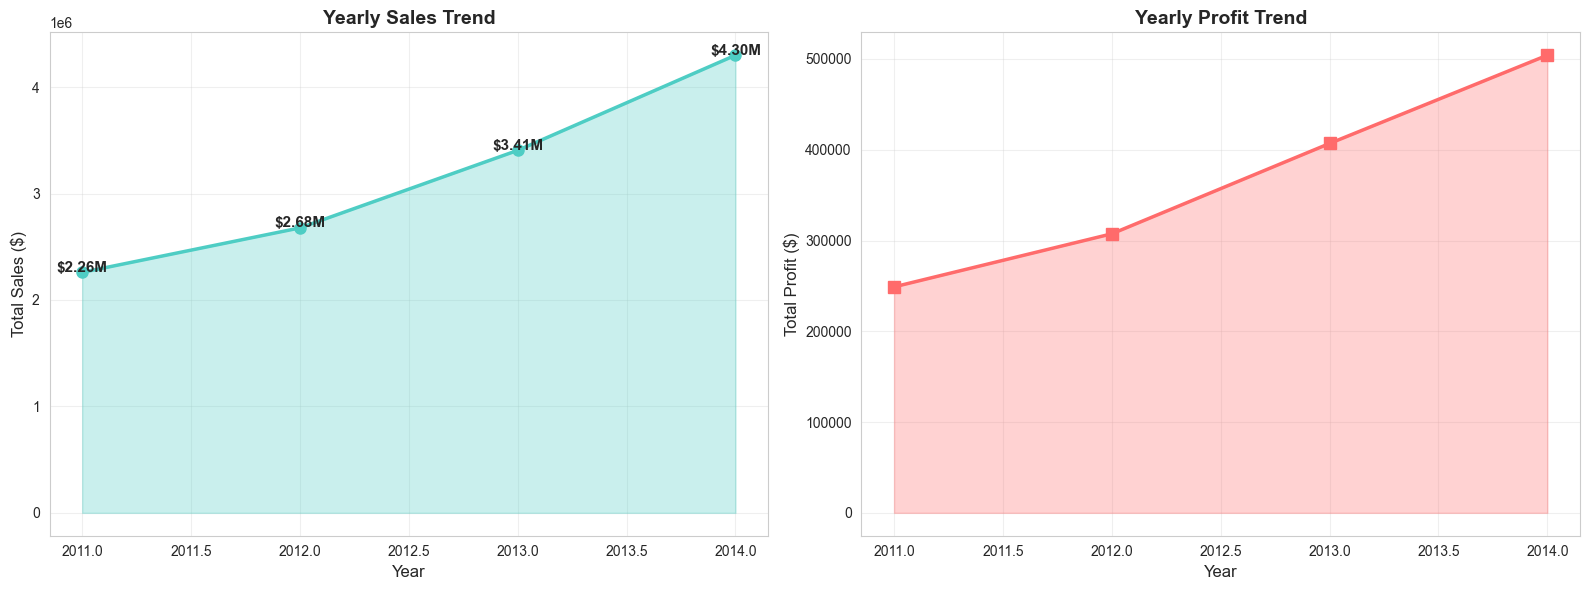

In [13]:
# ============================================================
# Step 11: Sales Trend Over Time
# ============================================================

if 'Year' in df.columns:
    # Yearly Sales Trend
    yearly_sales = df.groupby('Year').agg({
        'Sales': 'sum',
        'Profit': 'sum'
    }).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Sales Trend
    axes[0].plot(yearly_sales['Year'],
                 yearly_sales['Sales'],
                 marker='o', linewidth=2.5,
                 color='#4ECDC4', markersize=8)
    axes[0].fill_between(yearly_sales['Year'],
                         yearly_sales['Sales'],
                         alpha=0.3, color='#4ECDC4')
    axes[0].set_title('Yearly Sales Trend',
                       fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel('Total Sales ($)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    for x, y in zip(yearly_sales['Year'],
                    yearly_sales['Sales']):
        axes[0].text(x, y + 5000,
                     f'${y/1e6:.2f}M',
                     ha='center', fontsize=11,
                     fontweight='bold')

    # Profit Trend
    axes[1].plot(yearly_sales['Year'],
                 yearly_sales['Profit'],
                 marker='s', linewidth=2.5,
                 color='#FF6B6B', markersize=8)
    axes[1].fill_between(yearly_sales['Year'],
                         yearly_sales['Profit'],
                         alpha=0.3, color='#FF6B6B')
    axes[1].set_title('Yearly Profit Trend',
                       fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Year', fontsize=12)
    axes[1].set_ylabel('Total Profit ($)', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

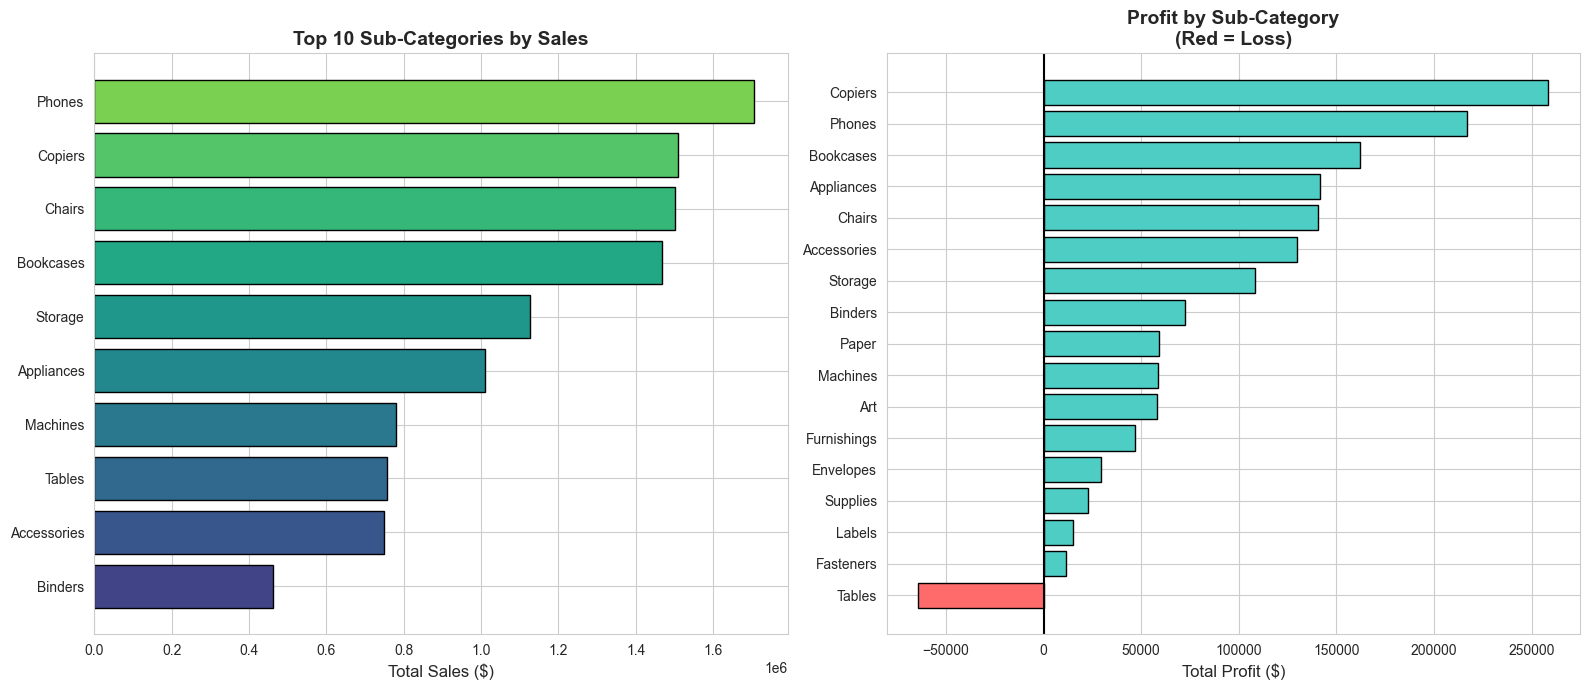

Loss Making Sub-Categories:
  Tables: $-64,083.39


In [14]:
# ============================================================
# Step 12: Top 10 Sub-Categories by Sales
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 Sub-Categories by Sales
top_subcats = df.groupby('Sub-Category')['Sales'].sum()\
               .sort_values(ascending=True).tail(10)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, 10))
axes[0].barh(top_subcats.index,
             top_subcats.values,
             color=colors, edgecolor='black')
axes[0].set_title('Top 10 Sub-Categories by Sales',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Sales ($)', fontsize=12)

# Profit by Sub-Category
profit_subcats = df.groupby('Sub-Category')['Profit'].sum()\
                  .sort_values(ascending=True)
bar_colors = ['#FF6B6B' if v < 0 else '#4ECDC4'
              for v in profit_subcats.values]
axes[1].barh(profit_subcats.index,
             profit_subcats.values,
             color=bar_colors, edgecolor='black')
axes[1].set_title('Profit by Sub-Category\n(Red = Loss)',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)', fontsize=12)
axes[1].axvline(x=0, color='black', linewidth=1.5)

plt.tight_layout()
plt.show()

# Loss making sub-categories
loss_cats = profit_subcats[profit_subcats < 0]
if len(loss_cats) > 0:
    print("Loss Making Sub-Categories:")
    for cat, profit in loss_cats.items():
        print(f"  {cat}: ${profit:,.2f}")

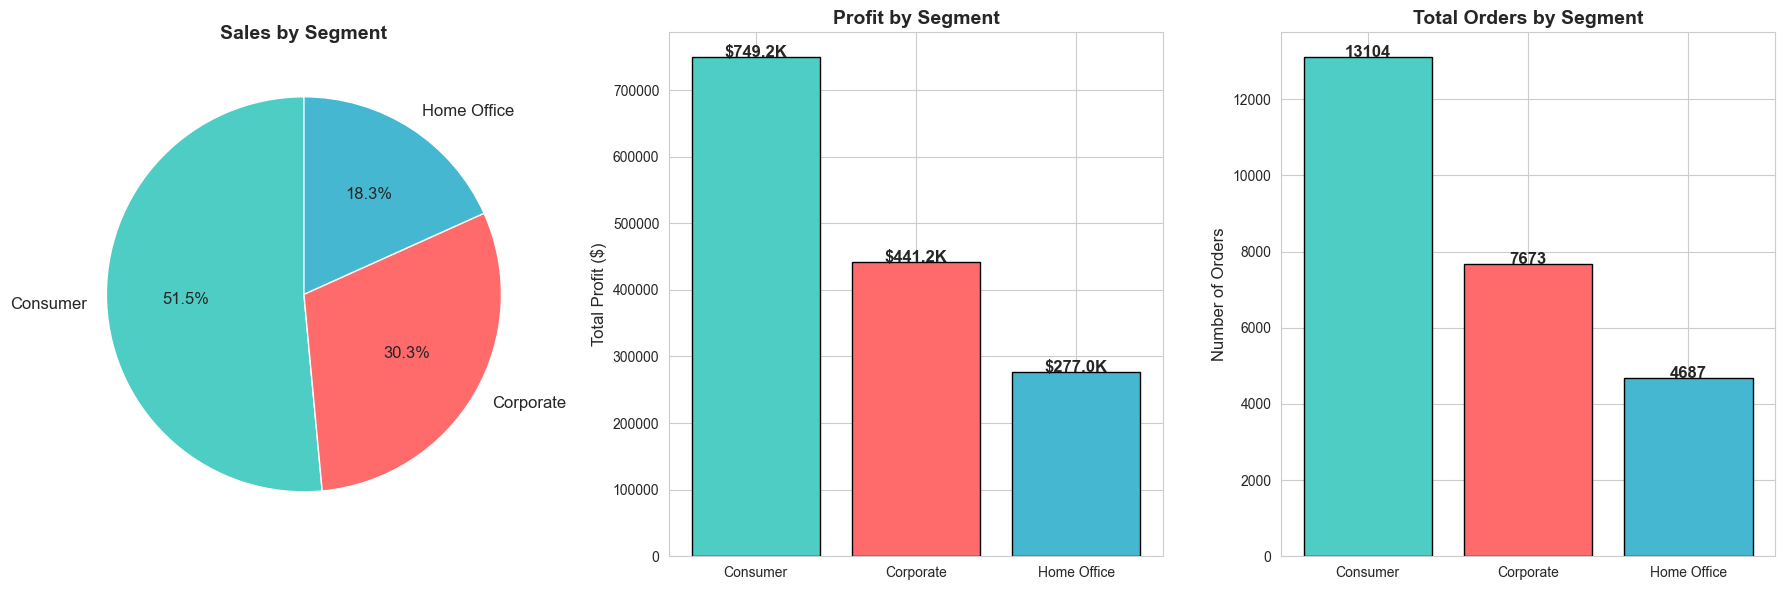

In [15]:
# ============================================================
# Step 13: Customer Segment Analysis
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

segments = df['Segment'].unique()
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']

# Sales by Segment
sales_by_seg = df.groupby('Segment')['Sales'].sum()
axes[0].pie(sales_by_seg.values,
            labels=sales_by_seg.index,
            colors=colors, autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Sales by Segment',
                   fontsize=14, fontweight='bold')

# Profit by Segment
profit_by_seg = df.groupby('Segment')['Profit'].sum()
bars = axes[1].bar(profit_by_seg.index,
                   profit_by_seg.values,
                   color=colors, edgecolor='black')
for bar, val in zip(bars, profit_by_seg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'${val/1e3:.1f}K',
                 ha='center', fontsize=12,
                 fontweight='bold')
axes[1].set_title('Profit by Segment',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)', fontsize=12)

# Orders by Segment
orders_by_seg = df.groupby('Segment')['Order ID'].nunique()
axes[2].bar(orders_by_seg.index,
            orders_by_seg.values,
            color=colors, edgecolor='black')
for i, (seg, val) in enumerate(orders_by_seg.items()):
    axes[2].text(i, val + 5, str(val),
                 ha='center', fontsize=12,
                 fontweight='bold')
axes[2].set_title('Total Orders by Segment',
                   fontsize=14, fontweight='bold')
axes[2].set_ylabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()

## Conclusion

### Key Findings from Global Superstore Analysis:

1. **Overall Performance**:
   - Business shows strong sales with consistent growth
   - Profit margins vary significantly by region and category
   - Technology category generates highest revenue

2. **Category Insights**:
   - Technology: Highest sales and profit
   - Furniture: High sales but lower profit margins
   - Office Supplies: Consistent performer

3. **Regional Performance**:
   - Sales distribution varies across regions
   - Some regions show negative profit (areas for improvement)

4. **Customer Insights**:
   - Top 5 customers contribute significantly to total revenue
   - Consumer segment has highest number of orders
   - Corporate segment shows strong profit margins

5. **Sub-Category Insights**:
   - Some sub-categories are loss-making (Tables, Bookcases)
   - Phones and Copiers are top performers

### Business Recommendations:
- Focus on Technology products for maximum profitability
- Investigate and fix loss-making sub-categories
- Target Corporate segment for higher profit margins
- Expand presence in high-performing regions